In [10]:
%pip install python-dotenv langchain-groq langgraph

Note: you may need to restart the kernel to use updated packages.


c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


In [11]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GROQ_API_KEY"):
    print("Groq API key is set.")
else:
    raise ValueError("Groq API key is not set.")

Groq API key is set.


In [12]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="llama-3.3-70b-versatile"
)
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016DF3BAC910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016DF3BAD090>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [13]:
from langchain_core.messages import HumanMessage

model.invoke([HumanMessage(content="I want to know the meaning of the water.")])

AIMessage(content='The concept of "the meaning of water" can be interpreted in various ways, depending on the context and perspective. Here are a few possible interpretations:\n\n1. **Symbolic meaning**: Water has been a symbol of life, renewal, and transformation across many cultures and traditions. It represents the cycle of birth, growth, and decay, and is often associated with emotions, intuition, and the subconscious.\n2. **Scientific meaning**: From a scientific perspective, water is a chemical compound (H2O) essential for life on Earth. It\'s a vital component of all living organisms, making up approximately 60% of the human body. Water plays a crucial role in regulating Earth\'s climate, weather patterns, and ecosystems.\n3. **Philosophical meaning**: Philosophers have explored the concept of water as a metaphor for the human condition. Water can represent the fluidity of life, the constant change and movement, and the interconnectedness of all things. It can also symbolize the

In [14]:
from typing import TypedDict,List,Annotated
from operator import add

class graph_schema(TypedDict):
    messages_manual:List
    #using reducer in langgraph
    
    messages_auto:Annotated[List,add]

In [15]:
from langchain_core.messages import AIMessage

def create_post(state: graph_schema) -> graph_schema:

    messages_manual = state['messages_manual']
    response_manual = model.invoke(messages_manual).content 
    response__manual_ai = AIMessage(content=response_manual)
    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = model.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]

    return state


def curate_post(state: graph_schema) -> graph_schema:


    messages_manual = state['messages_manual']

    response_manual = model.invoke(messages_manual).content
    response__manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = model.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]
    return state

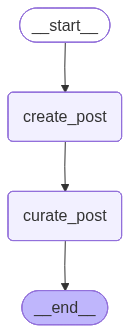

In [16]:

from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(messages_graph.get_graph().draw_mermaid_png())

In [19]:
messages_graph.invoke(
    {"messages_manual": [HumanMessage(content="The importance of data privacy in the digital age")],
     "messages_auto": [HumanMessage(content="The importance of data privacy in the digital age")]}
)


{'messages_manual': [HumanMessage(content='The importance of data privacy in the digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content="The importance of data privacy in the digital age cannot be overstated. As technology continues to advance and more aspects of our lives become digitized, the amount of personal data being collected, stored, and shared has increased exponentially. This has created a number of risks and challenges related to data privacy, including:\n\n1. **Identity theft**: With so much personal data available online, the risk of identity theft has increased significantly. Hackers and other malicious actors can use stolen data to impersonate individuals, access their financial information, and commit other types of fraud.\n2. **Surveillance**: The widespread collection and analysis of personal data has enabled governments, corporations, and other organizations to engage in mass surveillance, which can erode trust and undermine civil liberties.\